In [1]:
from ultralytics import YOLO
import torch
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import os
import clip
import faiss
from matplotlib import colors
from matplotlib import patches
import threading
from segment_anything import SamPredictor, sam_model_registry
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors
import threading
import cv2
import pandas as pd
from PIL import Image

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [3]:
PREDICT_ARGS = {
    # Detection Settings
    'conf': 0.2,  # object confidence threshold for detection
    'iou': 0.3,  # intersection over union (IoU) threshold for NMS
    'imgsz': 640,  # image size as scalar or (h, w) list, i.e. (640, 480)
    'half': False,  # use half precision (FP16)
    'device': None,  # device to run on, i.e. cuda device=0/1/2/3 or device=cpu
    'max_det': 300,  # maximum number of detections per image
    'vid_stride': False,  # video frame-rate stride
    'stream_buffer': False,  # buffer all streaming frames (True) or return the most recent frame (False)
    'visualize': False,  # visualize model features
    'augment': False,  # apply image augmentation to prediction sources
    'agnostic_nms': False,  # class-agnostic NMS
    'classes': None,  # filter results by class, i.e. classes=0, or classes=[0,2,3]
    'retina_masks': False,  # use high-resolution segmentation masks
    'embed': None,  # return feature vectors/embeddings from given layers

    # Visualization Settings
    'show': False,  # show predicted images and videos if environment allows
    'save': False,  # save predicted images and videos
    'save_frames': False,  # save predicted individual video frames
    'save_txt': False,  # save results as .txt file
    'save_conf': False,  # save results with confidence scores
    'save_crop': False,  # save cropped images with results
    'show_labels': True,  # show prediction labels, i.e. 'person'
    'show_conf': True,  # show prediction confidence, i.e. '0.99'
    'show_boxes': True,  # show prediction boxes
    'line_width': None  # line width of the bounding boxes. Scaled to image size if None.
    }

In [4]:

index_path = r"C:\Users\user\Documents\code\korean_food_detection\tools_6\faiss_index.index"
labels_path = r"C:\Users\user\Documents\code\korean_food_detection\tools_6\labels.npy"


In [5]:
yolo_model = YOLO(r'C:\Users\user\Documents\code\korean_food_detection\tools_6\food_detection_best.pt')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
sam_checkpoint = r"C:\Users\user\Documents\code\korean_food_detection\tools\sam_vit_b_01ec64.pth"
model_type = "vit_b"

In [7]:
class FoodImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for class_folder in os.listdir(root_dir):
            class_path = os.path.join(root_dir, class_folder)
            if os.path.isdir(class_path):
                for img_file in os.listdir(class_path):
                    img_path = os.path.join(class_path, img_file)
                    self.image_paths.append(img_path)
                    self.labels.append(class_folder)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
model, preprocess = clip.load("ViT-L/14@336px", device=device)

In [9]:
def load_faiss_index(index_path):
    index = faiss.read_index(index_path)
    print(f"FAISS index loaded from {index_path}")
    return index
def clip_transform(image):
    return preprocess(image)

In [10]:
def classify_image(model, faiss_index, image, transform, device, labels):
    """
    Classify an image using the CLIP model and FAISS index.

    Args:
    - model: The pre-trained CLIP model.
    - faiss_index: The FAISS index with image embeddings.
    - image: The input image to classify (PIL Image).
    - transform: The preprocessing transform used for the image (same as the one for training).
    - device: The device to run the model on (cuda or cpu).
    - labels: The list of labels corresponding to the FAISS index embeddings.

    Returns:
    - The predicted label for the given image or None if no match is found.
    """
    # Check if FAISS index is empty
    if faiss_index.ntotal == 0:
        print("FAISS index is empty, no embeddings available for search.")
        return None

    # Put model in evaluation mode
    model.eval()
    
    # Preprocess the input image
    with torch.no_grad():
        image = transform(image).unsqueeze(0).to(device)

        # Extract image features using the CLIP model
        image_features = model.encode_image(image).cpu().numpy()

        # Search in the FAISS index for the nearest neighbor
        distances, indices = faiss_index.search(image_features, k=1)  # k=1 to get the closest match

        # Check if we got a valid result
        if len(indices) == 0 or len(indices[0]) == 0:
            print("No match found in the FAISS index.")
            return None

        # Get the index of the closest match
        closest_idx = indices[0][0]

        # Check if the index is within the valid range of labels
        if closest_idx >= len(labels):
            print("Closest index is out of bounds for labels.")
            return None

        # Return the corresponding label
        predicted_label = labels[closest_idx]
        return predicted_label

In [11]:
def load_labels(labels_path):
    """
    Load labels from a saved numpy file.
    
    Args:
    - labels_path: Path to the saved labels file.
    
    Returns:
    - List of labels.
    """
    return np.load(labels_path, allow_pickle=True).tolist()

In [12]:
faiss_index = load_faiss_index(index_path)
labels = load_labels(labels_path)

FAISS index loaded from C:\Users\user\Documents\code\korean_food_detection\tools_6\faiss_index.index


In [13]:
def LoadSAMPredictor(sam_checkpoint, model_type, device='cuda', return_sam=False):
    """
    Load a Segment Anything Model (SAM) predictor model for semantic segmentation.

    Parameters:
    - sam_checkpoint (str): The path to the checkpoint file containing the SAM model's weights and configuration.
    - model_type (str): The SAM model type to use. It should be a key that corresponds to a model in the 'sam_model_registry'.
    - device (str, optional): The device to run the model on, either 'cuda' (GPU) or 'cpu' (CPU). Default is 'cuda'.

    Returns:
    - predictor (SamPredictor): An instance of the SAM predictor configured with the specified model type and loaded weights.
    """
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    sam.to(device=device)
    predictor = SamPredictor(sam)

    if return_sam :
        return predictor,sam
    else : 
        return predictor

In [14]:
sam_predictor = LoadSAMPredictor(sam_checkpoint, model_type, device='cuda', return_sam=False)

In [15]:
def load_calories_data(csv_path):
    """
    Load calories data from a CSV file.
    
    Parameters:
    -----------
    csv_path : str
        Path to the CSV file containing food names and calories
    
    Returns:
    --------
    dict
        A dictionary mapping food names to their calorie values
    """
    try:
        # calories_df = pd.read_csv(csv_path)
        calories_df = pd.read_excel(csv_path)
        # Assuming the CSV has columns 'food_name' and 'calories'
        return dict(zip(calories_df['food_name'], calories_df['calory_number']))
    except Exception as e:
        print(f"Error loading calories data: {e}")
        return {}

In [16]:
def get_food_calories(food_name, calories_dict):
    """
    Retrieve calorie information for a given food name.
    
    Parameters:
    -----------
    food_name : str
        Name of the food
    calories_dict : dict
        Dictionary of food names and their calorie values
    
    Returns:
    --------
    int
        Number of calories for the food, or 0 if not found
    """
    # Try exact match first, then case-insensitive match
    calories = calories_dict.get(food_name, 
                                 calories_dict.get(food_name.lower(), 
                                 calories_dict.get(food_name.title(), 0)))
    return calories

In [17]:
def run_sam_with_multiple_points(sam_predictor, input_point, bbox, all_masks, index):
    x1, y1, x2, y2 = bbox
    input_label = np.array([1])
    mask, _, _ = sam_predictor.predict(
        point_coords=np.array([input_point]),
        point_labels=input_label,
        box=np.array([x1, y1, x2, y2])[None, :],
        multimask_output=False,
    )
    all_masks[index] = mask[0]


0: 640x640 1 food, 67.4ms
Speed: 12.5ms preprocess, 67.4ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


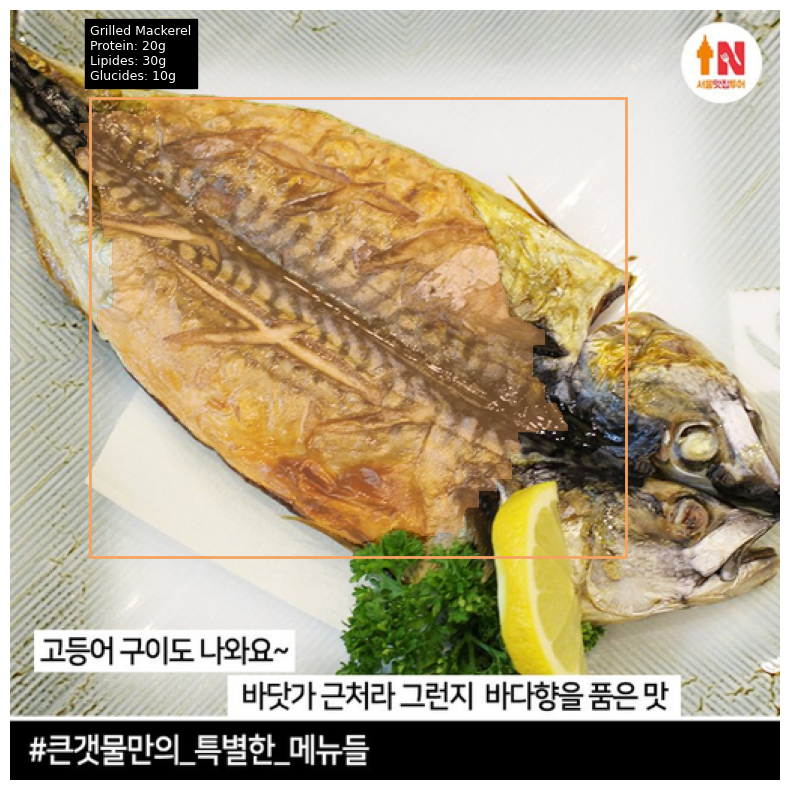

In [19]:


def load_nutrition_data(csv_path):
    """
    Load nutrition data from a CSV file.
    
    Parameters:
    -----------
    csv_path : str
        Path to the CSV file containing food names and nutrition values
    
    Returns:
    --------
    dict
        A dictionary mapping food names to their nutritional values
    """
    try:
        nutrition_df = pd.read_excel(csv_path)
        # Create a dictionary with all nutrition columns
        return nutrition_df.set_index('food_name').to_dict(orient='index')
    except Exception as e:
        print(f"Error loading nutrition data: {e}")
        return {}

def get_food_nutrition(food_name, nutrition_dict):
    """
    Retrieve nutrition information for a given food name.
    
    Parameters:
    -----------
    food_name : str
        Name of the food
    nutrition_dict : dict
        Dictionary of food names and their nutritional values
    
    Returns:
    --------
    dict or None
        Nutritional values for the food, or None if not found
    """
    # Try variations of food name matching
    return nutrition_dict.get(food_name) or \
           nutrition_dict.get(food_name.lower()) or \
           nutrition_dict.get(food_name.title())


def plot_food_detection_with_nutrition(image_path, 
                                       yolo_model, 
                                       sam_predictor, 
                                       model, 
                                       faiss_index, 
                                       clip_transform, 
                                       device, 
                                       labels, 
                                       nutrition_csv_path):
    """
    Detect and classify food items with conditional nutrition information display.

    Parameters:
    -----------
    image_path : str
        Path to the input image
    yolo_model : object
        YOLO detection model
    sam_predictor : object
        Segment Anything Model predictor
    model : object
        CLIP model for classification
    faiss_index : object
        FAISS index for similarity search
    clip_transform : object
        Image transformation for CLIP
    device : str
        Computing device (cuda/cpu)
    labels : list
        List of food labels
    nutrition_csv_path : str
        Path to CSV file with nutrition information
    """
    # Load nutrition data
    nutrition_dict = load_nutrition_data(nutrition_csv_path)
    
    # Image preprocessing
    image = Image.open(image_path).convert('RGB')
    new_width = 512
    aspect_ratio = new_width / image.width
    new_height = int(image.height * aspect_ratio)
    image = image.resize((new_width, new_height), Image.LANCZOS)
    image_np = np.array(image)

    # Detect objects with YOLO
    detection_results = yolo_model(image, **PREDICT_ARGS)

    # Predefined colormap for bounding boxes
    colors_list = list(colors.CSS4_COLORS.keys())
    np.random.seed(42)
    random_colors = np.random.choice(colors_list, size=len(detection_results[0].boxes), replace=False)

    # Set the image for SAM predictor
    sam_predictor.set_image(image_np)

    # Initialize storage for masks
    all_masks = [None] * len(detection_results[0].boxes)

    # Plot image with detection results
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image_np)

    if len(detection_results) > 0:
        detections = detection_results[0].boxes.xyxy
        threads = []

        for i, detection in enumerate(detections):
            x1, y1, x2, y2 = map(int, detection[:4].tolist())

            # Classify the cropped image using CLIP+FAISS
            cropped_image = Image.fromarray(image_np[y1:y2, x1:x2])
            predicted_label = classify_image(model, faiss_index, cropped_image, clip_transform, device, labels)

            # Get nutrition for the detected food
            nutrition_info = get_food_nutrition(predicted_label, nutrition_dict)

            # Plot the bounding box from YOLO
            color = random_colors[i]
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, 
                                     linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)

            # Prepare nutrition text conditionally
            if nutrition_info:
                nutrition_text = (
                    f'{predicted_label}\n'
                    f'Protein: {nutrition_info.get("protein", 0)}g\n'
                    f'Lipides: {nutrition_info.get("lipides", 0)}g\n'
                    f'Glucides: {nutrition_info.get("glucides", 0)}g'
                )
            else:
                nutrition_text = f'{predicted_label}'

            # Display predicted label and nutrition info
            # ax.text(x1, y1 - 50, nutrition_text, 
            #         color='white', fontsize=9, 
            #         backgroundcolor=color, 
            #         verticalalignment='top')
            ax.text(
            x1, y1 - 10,  # Slightly above the bounding box
            nutrition_text, 
            color='white', 
            fontsize=9, 
            backgroundcolor='black',  # Ensure readability
            verticalalignment='bottom',  # Align closer to the image
            horizontalalignment='left'  # Left-aligned text
        )

            # Generate SAM mask using the custom function
            center_x, center_y = (x1 + x2) // 2, (y1 + y2) // 2
            input_point = np.array([center_x, center_y])
            bbox = [x1, y1, x2, y2]
            thread = threading.Thread(target=run_sam_with_multiple_points, 
                                      args=(sam_predictor, input_point, bbox, all_masks, i))
            thread.start()
            threads.append(thread)

        # Wait for all threads to finish
        for thread in threads:
            thread.join()

        # Post-process and display masks for each detection
        for i, mask in enumerate(all_masks):
            if mask is not None:
                binary_mask = (mask > 0.5).astype(np.uint8)
                kernel = np.ones((5, 5), np.uint8)
                binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
                binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)

                # Find contours and select the largest one
                contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                if contours:
                    largest_contour = max(contours, key=cv2.contourArea)

                    refined_mask = np.zeros_like(binary_mask)
                    cv2.drawContours(refined_mask, [largest_contour], 0, 1, -1)

                    # Plot the refined segmentation mask
                    color_rgba = colors.to_rgba(random_colors[i], alpha=0.4)
                    mask_overlay = np.zeros((*refined_mask.shape, 4), dtype=np.float32)
                    mask_overlay[refined_mask == 1] = color_rgba
                    ax.imshow(mask_overlay)
    else:
        print("No objects detected.")

    # Show the image with bounding boxes, segmentation masks, labels, and nutrition info
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage
nutrition_csv_path = r'C:\Users\user\Documents\code\korean_food_detection\New Feuille de calcul Microsoft Excel.xlsx'
# image_path = r'C:\Users\user\Documents\code\korean_food_detection\Data_cleaning\merge_data\train\Chicken Teriyaki\28_crop_0.jpg'
image_path=r'C:\Users\user\Documents\code\korean_food_detection\korean_cheat_lite\train\Grilled Mackerel\Img_002_0969.jpg'

plot_food_detection_with_nutrition(
    image_path, 
    yolo_model, 
    sam_predictor, 
    model, 
    faiss_index, 
    clip_transform, 
    device, 
    labels, 
    nutrition_csv_path
)